In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart_disease_prediction.csv')
df.head()

,id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
0,1,77,Female,Non-Anginal Pain,120,542,0,Left Ventricular Hypertrophy,185,No,3.9,Upsloping,Reversible Defect,1
1,2,51,Female,Asymptomatic,192,423,1,ST-T Wave Abnormality,78,No,6.3,Flat,Fixed Defect,1
2,3,79,Female,Atypical Angina,182,557,1,ST-T Wave Abnormality,111,No,4.7,Flat,Normal,1
3,4,74,Male,Typical Angina,102,159,1,Normal,147,No,5.1,Flat,Normal,1
4,5,54,Male,Non-Anginal Pain,183,278,0,ST-T Wave Abnormality,195,Yes,4.3,Upsloping,Normal,1


In [4]:

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

print("\n--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) 

missing_pct = (df.isnull().sum() / len(df)) * 100
print("\n--- Missing Values Percentage ---")
print(missing_pct[missing_pct > 0])

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

print("\n--- Summary Statistics (Numerical) ---")
display(df.describe().T)


categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print("\n--- Summary Statistics (Categorical) ---")
    display(df.describe(include=['object', 'category']).T)
    
    print("\n--- Unique Values in Categorical Columns ---")
    for col in categorical_cols:
        print(f"{col}: {df[col].nunique()} unique values")


Dataset Shape: 54897 rows and 14 columns

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54897 entries, 0 to 54896
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   54897 non-null  int64  
 1   age                  54897 non-null  int64  
 2   gender               54897 non-null  object 
 3   chest_pain_type      54897 non-null  object 
 4   resting_bp           54897 non-null  int64  
 5   cholesterol          54897 non-null  int64  
 6   fasting_blood_sugar  54897 non-null  int64  
 7   resting_ecg          54897 non-null  object 
 8   max_heart_rate       54897 non-null  int64  
 9   exercise_angina      54897 non-null  object 
 10  oldpeak              54897 non-null  float64
 11  slope                54897 non-null  object 
 12  thal                 54897 non-null  object 
 13  heart_disease        54897 non-null  int64  
dtypes: float64(1), int64(7), o

,count,mean,std,min,25%,50%,75%,max
id,54897.0,27449.000000,15847.543201,1.0,13725.0,27449.0,41173.0,54897.0
age,54897.0,53.987012,21.100459,18.0,36.0,54.0,72.0,90.0
resting_bp,54897.0,140.090970,34.984844,80.0,110.0,140.0,171.0,200.0
cholesterol,54897.0,349.458750,144.254318,100.0,224.0,350.0,474.0,600.0
fasting_blood_sugar,54897.0,0.499481,0.500004,0.0,0.0,0.0,1.0,1.0
max_heart_rate,54897.0,130.731989,41.372311,60.0,95.0,131.0,166.0,202.0
oldpeak,54897.0,3.238667,1.876753,0.0,1.6,3.2,4.9,6.5
heart_disease,54897.0,0.788495,0.408379,0.0,1.0,1.0,1.0,1.0



--- Summary Statistics (Categorical) ---


,count,unique,top,freq
gender,54897,2,Male,27451
chest_pain_type,54897,4,Asymptomatic,13824
resting_ecg,54897,3,Left Ventricular Hypertrophy,18369
exercise_angina,54897,2,Yes,27500
slope,54897,3,Upsloping,18339
thal,54897,3,Normal,18438



--- Unique Values in Categorical Columns ---
gender: 2 unique values
chest_pain_type: 4 unique values
resting_ecg: 3 unique values
exercise_angina: 2 unique values
slope: 3 unique values
thal: 3 unique values


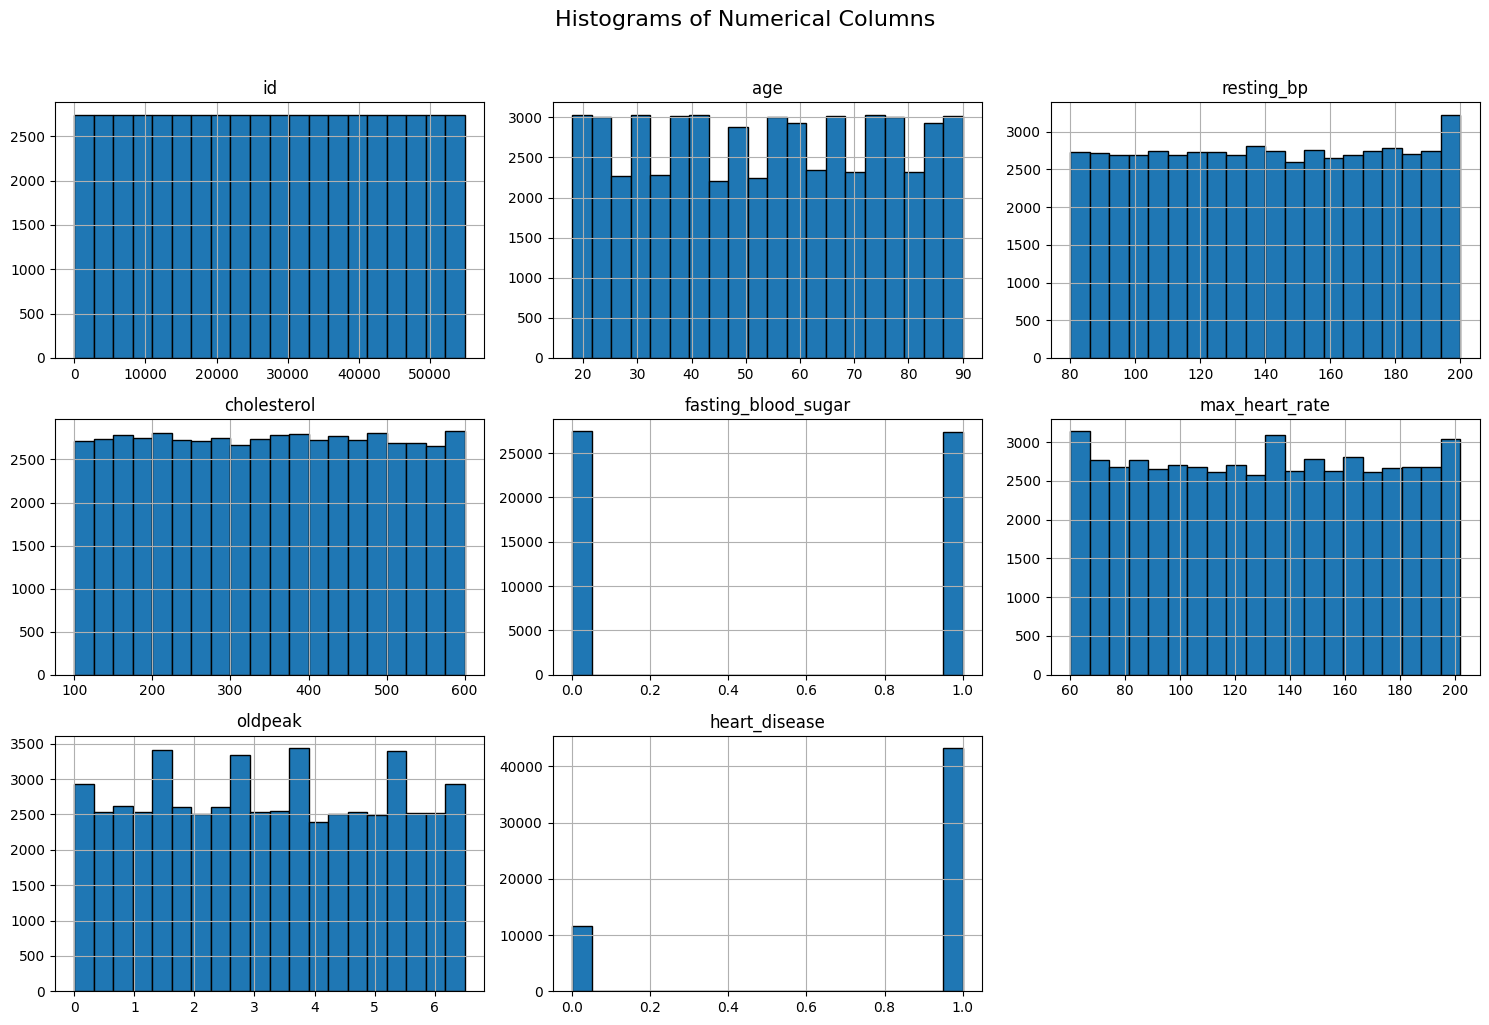

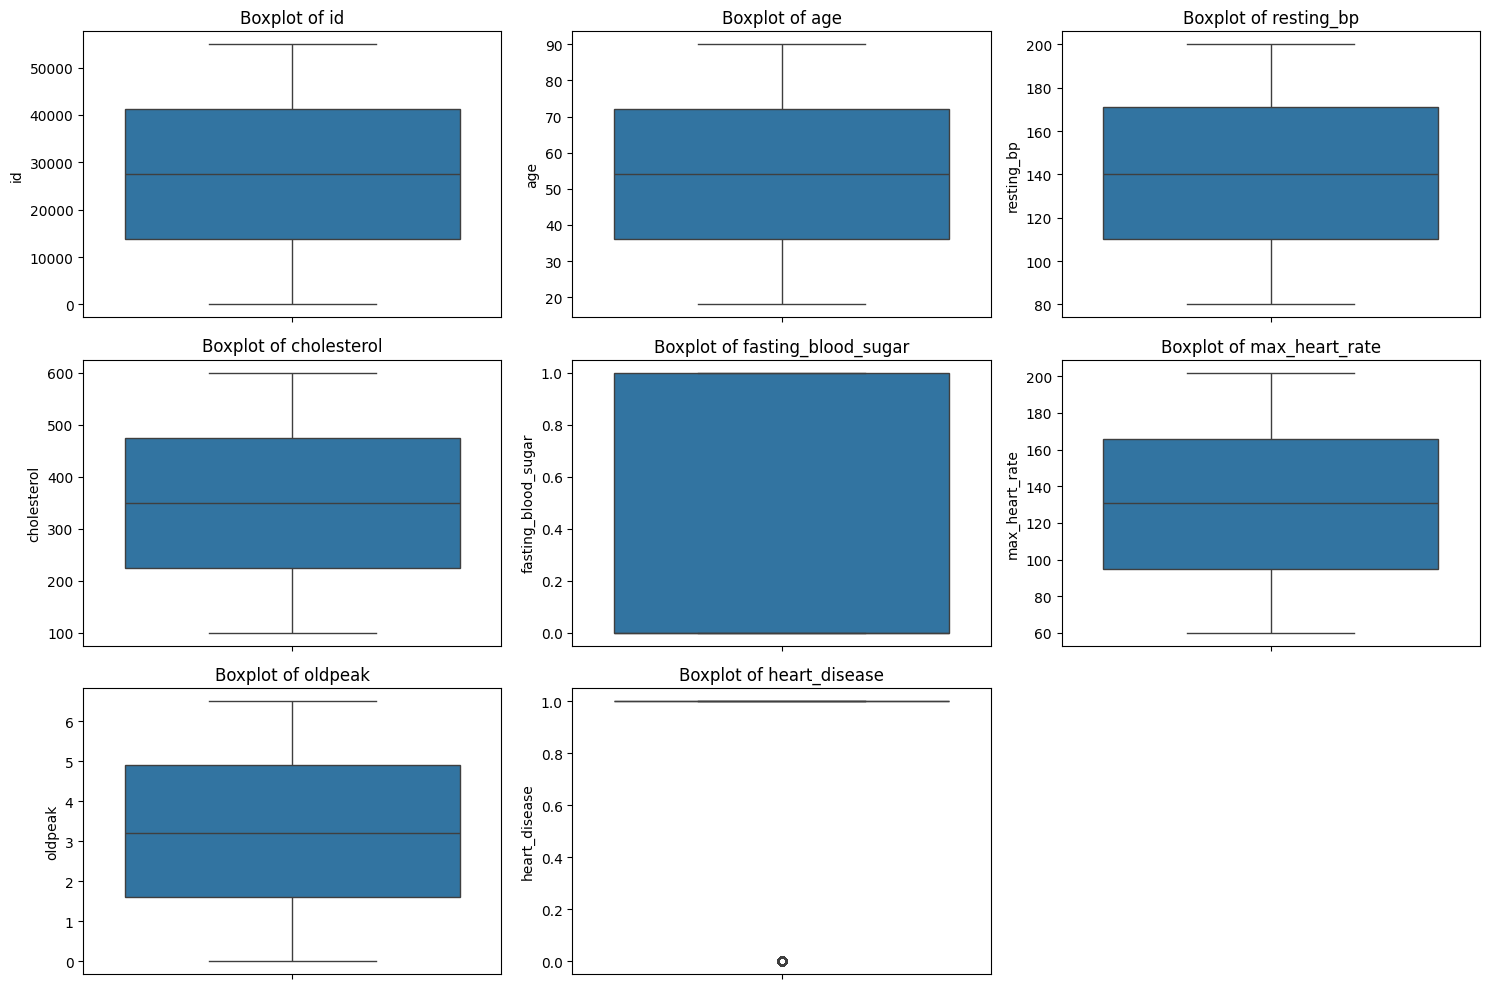

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numerical Columns", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(int(np.ceil(len(numerical_cols)/3)), 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()



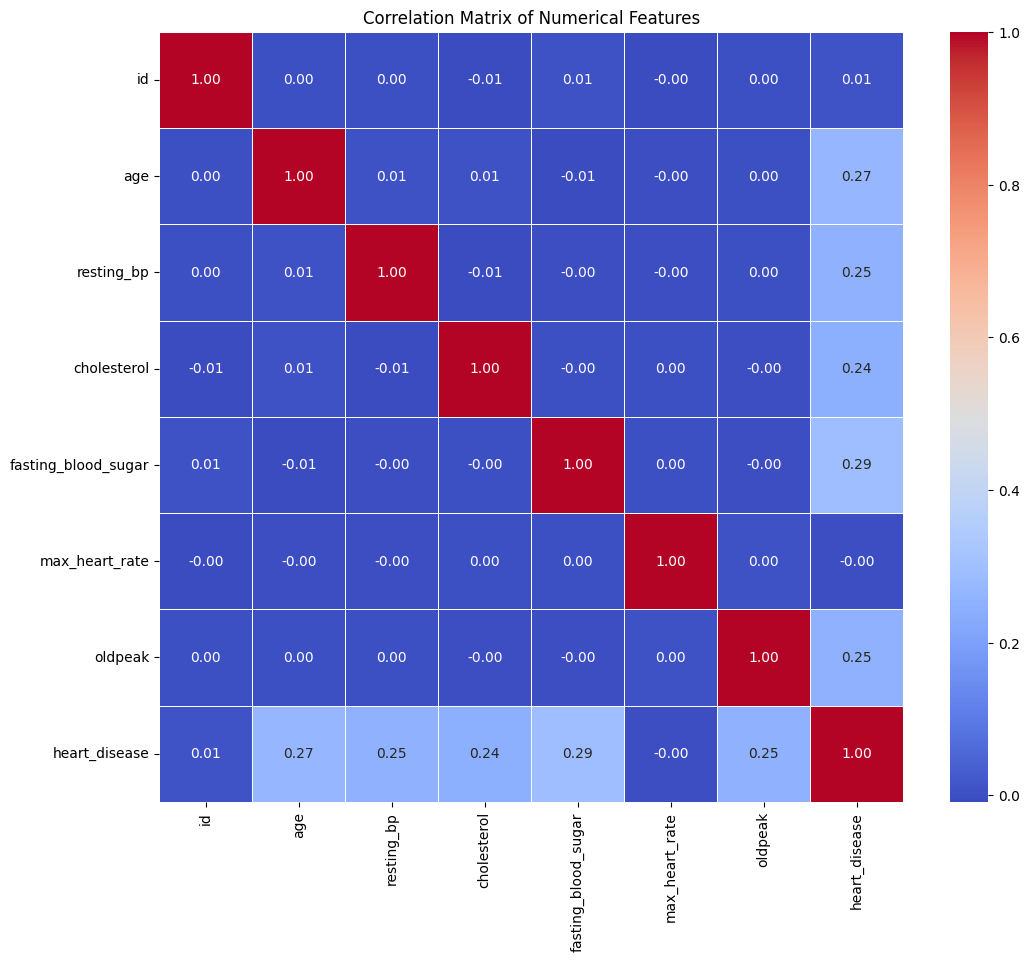

In [11]:
# Assume target_col is your dependent variable (change accordingly, e.g., 'HeartDisease', 'target')
# target_col = 'target_column_name' 

# 4.1 Correlation Matrix (Numerical vs Numerical)
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()



In [13]:
# 6.1 Identifying Outliers using IQR (Interquartile Range) Method
def get_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers

print("--- Outlier Count using IQR ---")
for col in numerical_cols:
    outliers_df = get_outliers_iqr(df.dropna(subset=[col]), col)
    print(f"{col}: {len(outliers_df)} outliers")


--- Outlier Count using IQR ---
id: 0 outliers
age: 0 outliers
resting_bp: 0 outliers
cholesterol: 0 outliers
fasting_blood_sugar: 0 outliers
max_heart_rate: 0 outliers
oldpeak: 0 outliers
heart_disease: 11611 outliers
